In [134]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from pprint import pprint

import contextily as ctx


data_dir = '/Users/jcolen/Documents/chkd_toy_problem/data'

/var/folders/cl/t908rv_96mz1n31np3qj1n080000gp/T/ipykernel_50813/2206313594.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hampton_roads_region = hampton_roads.to_crs(zdf.crs).geometry.unary_union


EPSG:4269 EPSG:4269


,ZCTA5CE20,geometry
5673,27818,"POLYGON ((-77.16438 36.54633, -77.16432 36.546..."
5677,27950,"POLYGON ((-76.15427 36.54023, -76.15387 36.540..."
7404,23128,"MULTIPOLYGON (((-76.45022 37.43022, -76.45002 ..."
7407,23314,"POLYGON ((-76.58686 36.93857, -76.58619 36.938..."
7410,23462,"POLYGON ((-76.19498 36.83293, -76.19495 36.833..."
...,...,...
25528,23878,"POLYGON ((-77.09782 36.86998, -77.09421 36.871..."
33723,23668,"POLYGON ((-76.34185 37.02094, -76.34181 37.021..."
33733,23667,"POLYGON ((-76.33635 37.02244, -76.33578 37.022..."
33784,23681,"POLYGON ((-76.39395 37.10615, -76.39345 37.108..."


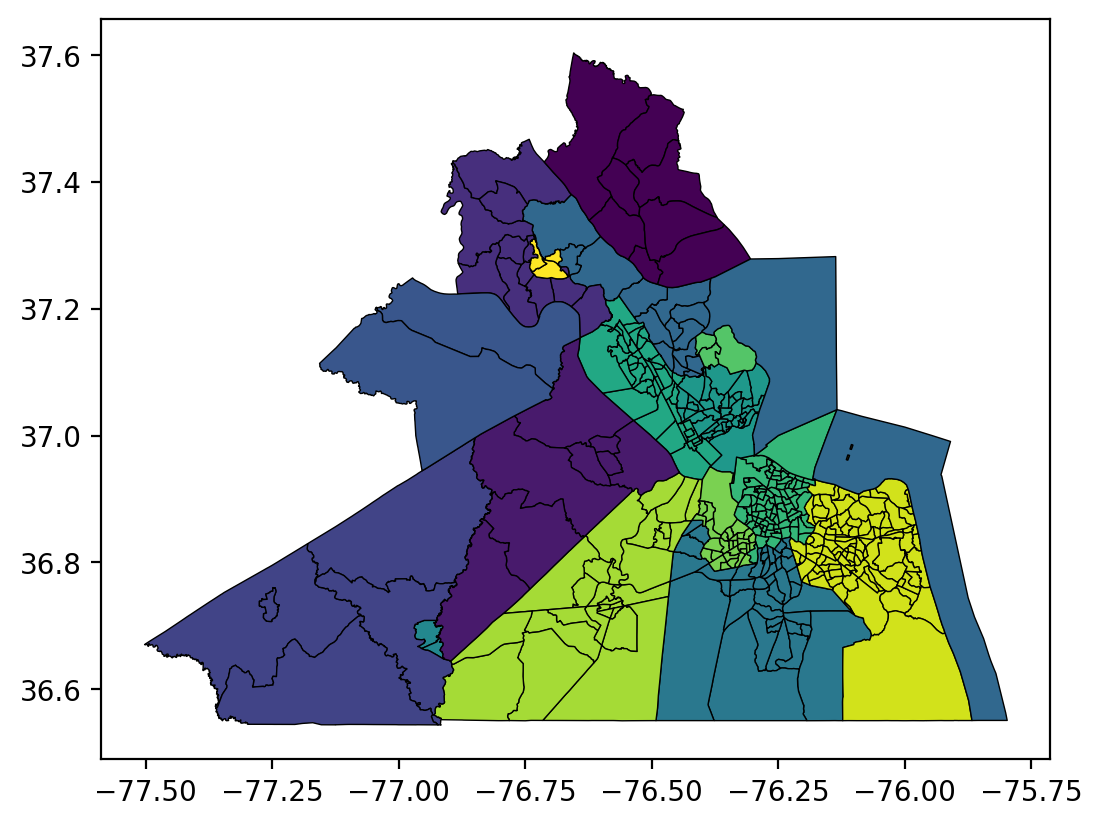

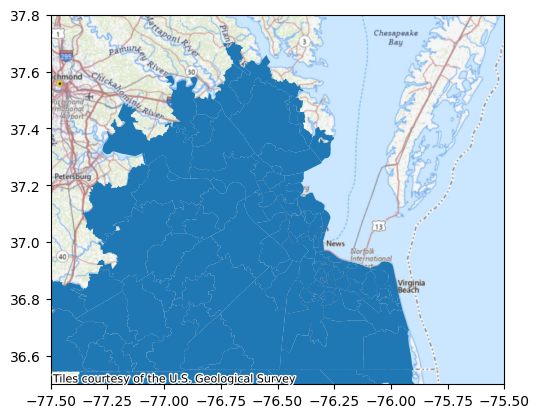

In [135]:
zdf = gpd.read_file(f'{data_dir}/tl_2020_us_zcta520')
zdf['ZCTA5CE20'] = zdf['ZCTA5CE20'].astype(str).str.zfill(5)

hampton_roads = gpd.read_file(f'{data_dir}/Hampton_Roads_2010_Census_Blocks').dissolve('TRACT')
hampton_roads = hampton_roads.to_crs(zdf.crs)

fig, ax = plt.subplots(1, 1, dpi=200)
hampton_roads.plot(ax=ax, edgecolor='black', linewidth=0.5, cmap='viridis', column='COUNTY')


hampton_roads_region = hampton_roads.to_crs(zdf.crs).geometry.unary_union
zdf = zdf[zdf.intersects(hampton_roads_region)].loc[:, ['ZCTA5CE20', 'geometry']]

print(hampton_roads.crs, zdf.crs)

zdf.plot()
plt.xlim([-77.5, -75.5])
plt.ylim([36.5, 37.8])

ctx.add_basemap(plt.gca(), source=ctx.providers.USGS.USTopo, crs=zdf.crs)

zdf

,ZCTA5CE20,geometry,count
0,27818,"POLYGON ((-77.16438 36.54633, -77.16432 36.546...",10.0
1,27950,"POLYGON ((-76.15427 36.54023, -76.15387 36.540...",189.0
2,23128,"MULTIPOLYGON (((-76.45022 37.43022, -76.45002 ...",57.0
3,23314,"POLYGON ((-76.58686 36.93857, -76.58619 36.938...",648.0
4,23462,"POLYGON ((-76.19498 36.83293, -76.19495 36.833...",9139.0
...,...,...,...
117,23878,"POLYGON ((-77.09782 36.86998, -77.09421 36.871...",60.0
118,23668,"POLYGON ((-76.34185 37.02094, -76.34181 37.021...",3.0
119,23667,"POLYGON ((-76.33635 37.02244, -76.33578 37.022...",4.0
120,23681,"POLYGON ((-76.39395 37.10615, -76.39345 37.108...",0.0


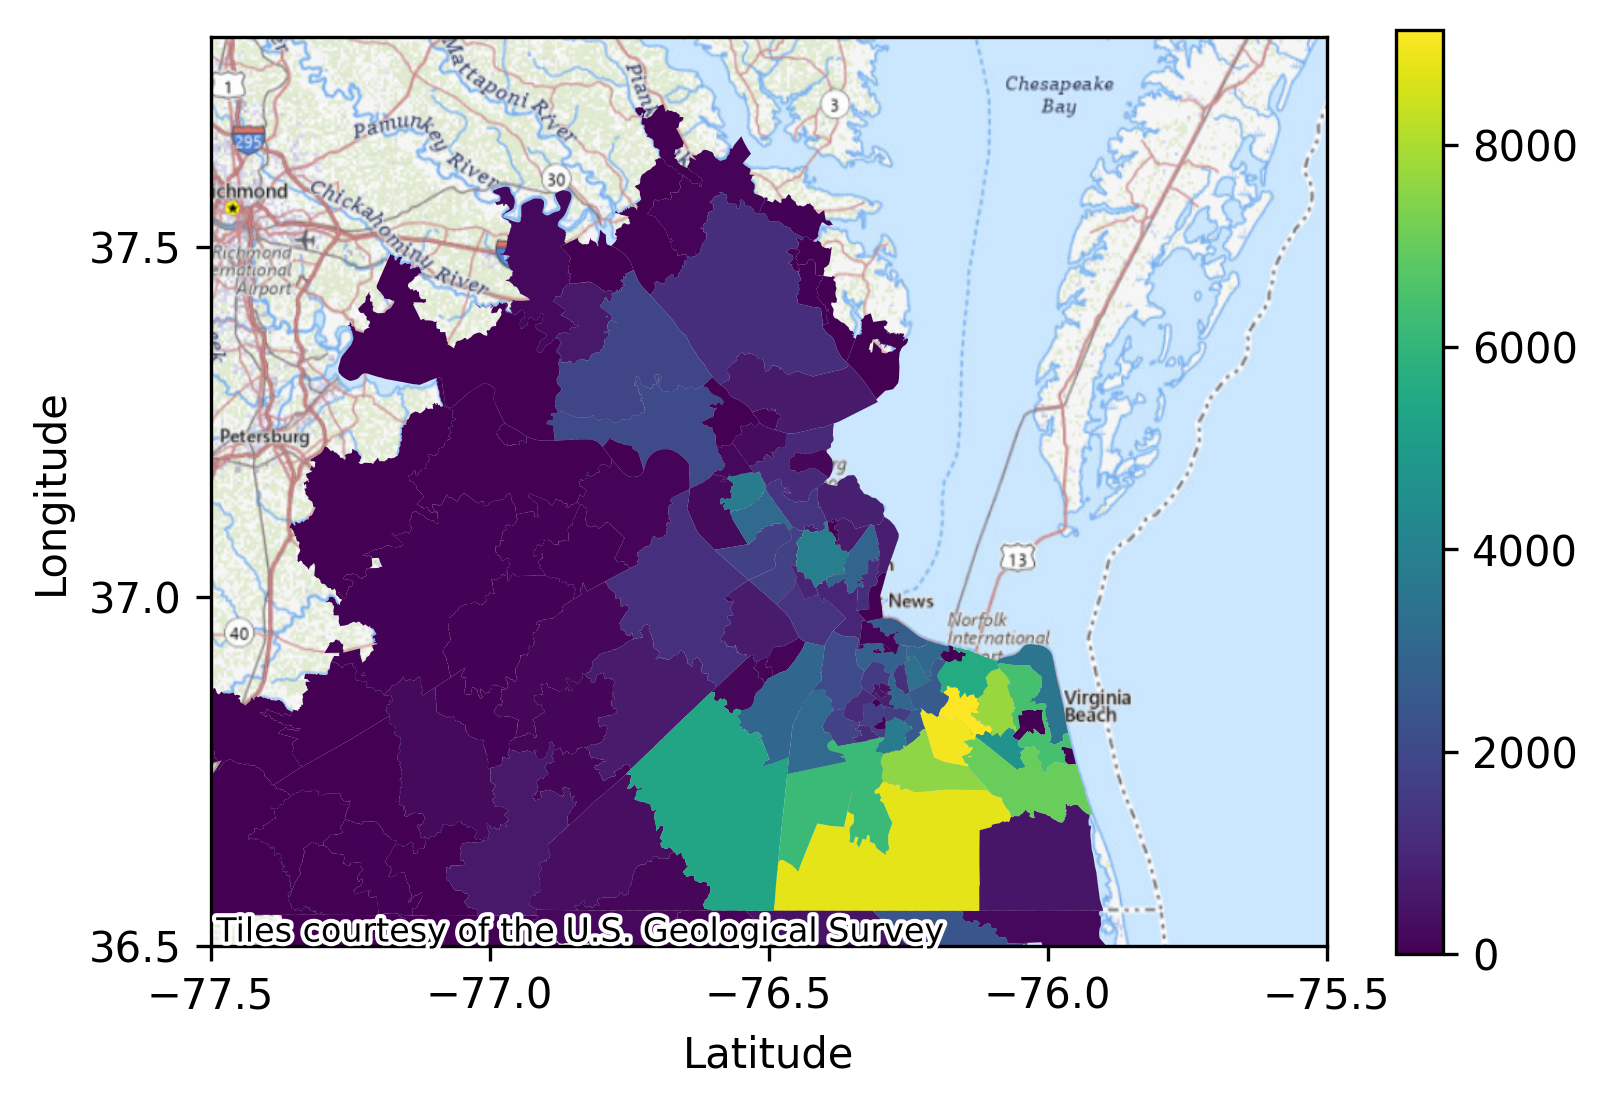

In [131]:
patient_df = pd.read_csv(f'{data_dir}/Toy Project Outgoing.csv', low_memory=False, index_col='INDEX_ID')
patient_df['PATIENT_ZIPCODE'] = patient_df['PATIENT_ZIPCODE'].astype(str).str.zfill(5)
patient_df['DATE_OF_SERVICE'] = pd.to_datetime(patient_df['DATE_OF_SERVICE'])

counts = patient_df['PATIENT_ZIPCODE'].value_counts().reset_index()


fig, ax = plt.subplots(1, figsize=(6, 4), dpi=300, sharex=True, sharey=True)

# Plot a map colored by the number of patients in each zip codes

#counts = counts[(counts['count'] > 1000) & counts['PATIENT_ZIPCODE'].str.startswith('23')]
counts = counts.rename(columns={'PATIENT_ZIPCODE': 'ZCTA5CE20'})
merged = zdf.merge(counts, on='ZCTA5CE20', how='left').fillna(0)

merged.plot(column='count', ax=ax, legend=True, cmap='viridis')

ax.set(
    xlabel='Latitude', xlim=[-77.5, -75.5], xticks=[-77.5, -77, -76.5, -76, -75.5],
    ylabel='Longitude', ylim=[36.5, 37.8], yticks=[36.5, 37, 37.5],
)
ax.set_xlabel('Latitude')

ctx.add_basemap(ax, source=ctx.providers.USGS.USTopo, crs=merged.crs)

merged

In [132]:
census_zcta = pd.read_csv(f'{data_dir}/DECENNIALDP2020.DP1_2025-01-27T131504/DECENNIALDP2020.DP1-Data.csv', skiprows=[1])

# We care about TOTAL population and TOTAL population 0-19 years
census_zcta = census_zcta.loc[:, ['NAME', 'DP1_0001C', 'DP1_0002C', 'DP1_0003C', 'DP1_0004C', 'DP1_0005C']] \
    .rename({
        'NAME': 'ZCTA5',
        'DP1_0001C': 'Total Population',
        'DP1_0002C': 'Pop 0y-5y',
        'DP1_0003C': 'Pop 5y-9y',
        'DP1_0004C': 'Pop 10y-14y',
        'DP1_0005C': 'Pop 15y-19y',
    }, axis=1)

census_zcta['Population 0-19y'] = census_zcta.iloc[:, -4:].sum(axis=1)
census_zcta = census_zcta.drop(['Pop 0y-5y', 'Pop 5y-9y', 'Pop 10y-14y', 'Pop 15y-19y'], axis=1)
census_zcta['ZCTA5'] = census_zcta['ZCTA5'].str.replace('ZCTA5 ', '')

zcta_info = zdf.loc[:, ['ZCTA5CE20', 'geometry']].merge(
    census_zcta.rename({'ZCTA5': 'ZCTA5CE20'}, axis=1), on='ZCTA5CE20', how='left')

zcta_info.to_file(f'{data_dir}/Hampton_Roads_ZCTA_Populations.shp')

zcta_info

/var/folders/cl/t908rv_96mz1n31np3qj1n080000gp/T/ipykernel_50813/724843486.py:21: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  zcta_info.to_file(f'{data_dir}/Hampton_Roads_ZCTA_Populations.shp')
/Users/jcolen/miniconda3/envs/clinical_informatics_env/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'Total Population' to 'Total Popu'
  ogr_write(
/Users/jcolen/miniconda3/envs/clinical_informatics_env/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'Population 0-19y' to 'Population'
  ogr_write(


,ZCTA5CE20,geometry,Total Population,Population 0-19y
0,27818,"POLYGON ((-77.16438 36.54633, -77.16432 36.546...",1159,204
1,27950,"POLYGON ((-76.15427 36.54023, -76.15387 36.540...",1918,394
2,23128,"MULTIPOLYGON (((-76.45022 37.43022, -76.45002 ...",707,126
3,23314,"POLYGON ((-76.58686 36.93857, -76.58619 36.938...",9523,2452
4,23462,"POLYGON ((-76.19498 36.83293, -76.19495 36.833...",68045,16615
...,...,...,...,...
117,23878,"POLYGON ((-77.09782 36.86998, -77.09421 36.871...",1162,277
118,23668,"POLYGON ((-76.34185 37.02094, -76.34181 37.021...",739,497
119,23667,"POLYGON ((-76.33635 37.02244, -76.33578 37.022...",80,8
120,23681,"POLYGON ((-76.39395 37.10615, -76.39345 37.108...",0,0


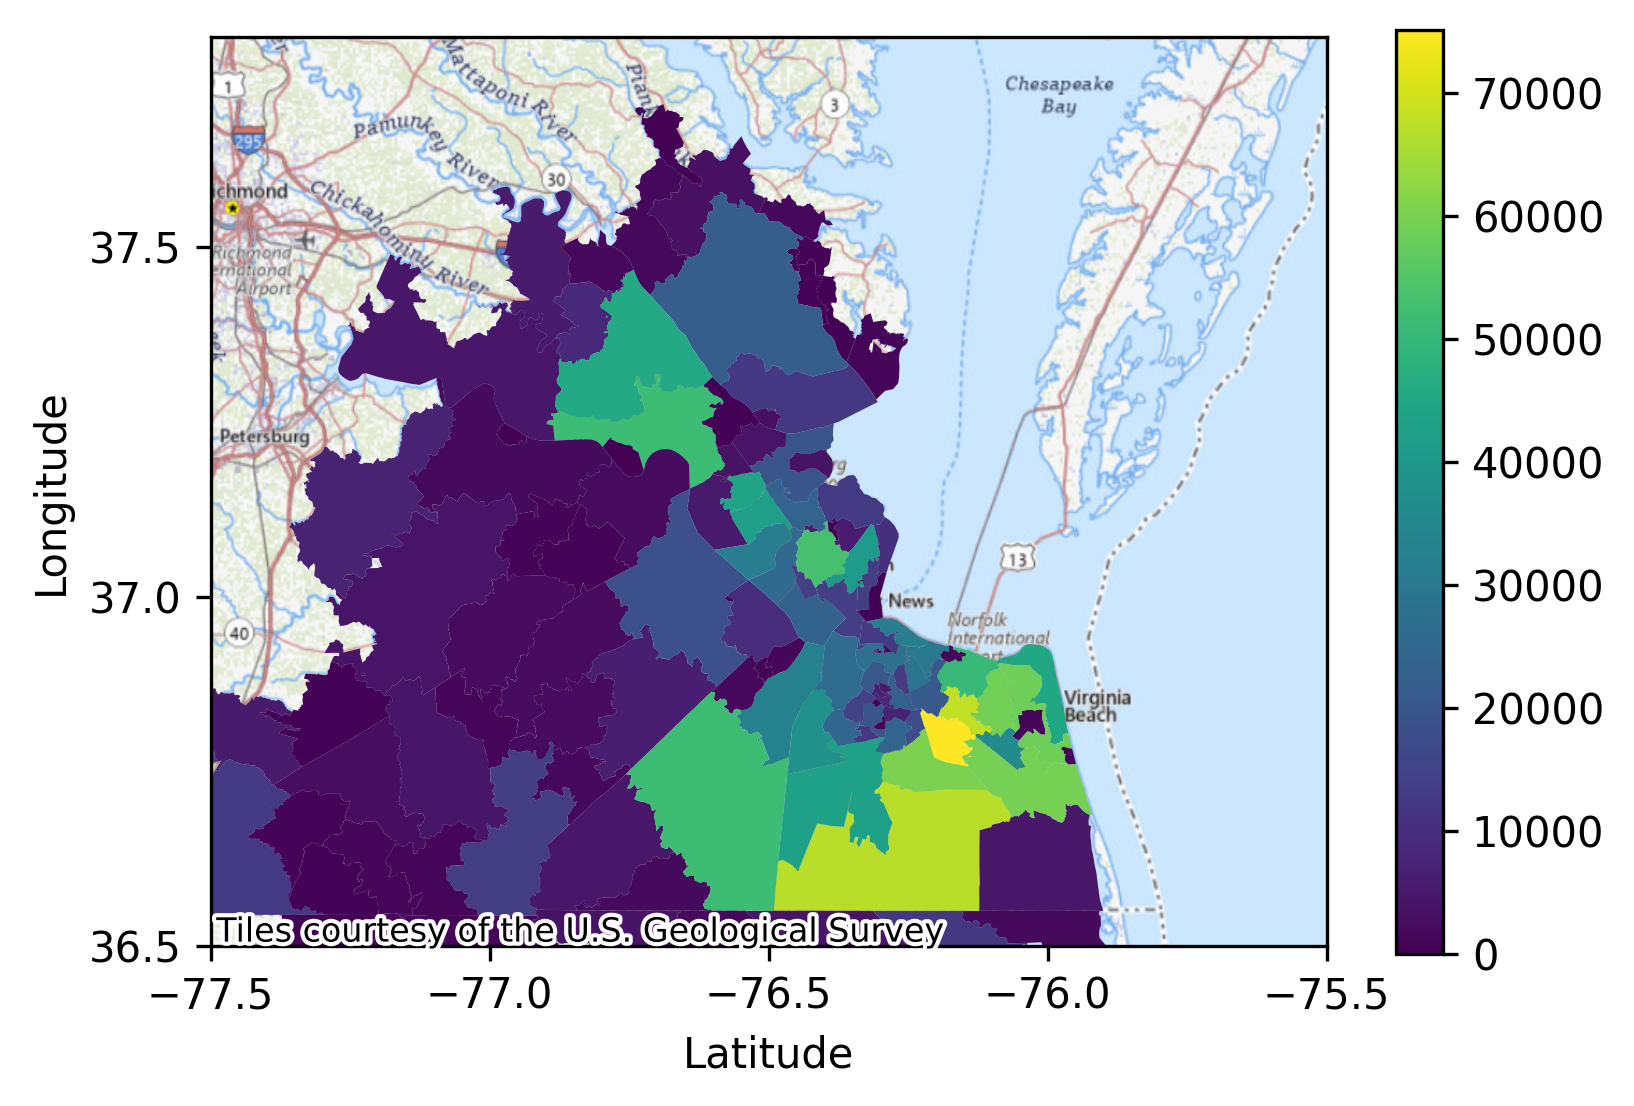

In [133]:
fig, ax = plt.subplots(1, figsize=(6, 4), dpi=300, sharex=True, sharey=True)

# Plot a map colored by the population in each zip codes
zcta_info.plot(column='Total Population', ax=ax, legend=True, cmap='viridis')

ax.set(
    xlabel='Latitude', xlim=[-77.5, -75.5], xticks=[-77.5, -77, -76.5, -76, -75.5],
    ylabel='Longitude', ylim=[36.5, 37.8], yticks=[36.5, 37, 37.5],
)
ax.set_xlabel('Latitude')

ctx.add_basemap(ax, source=ctx.providers.USGS.USTopo, crs=zcta_info.crs)

In [43]:
census_row_info = pd.read_csv(f'{data_dir}/DECENNIALDP2020.DP1_2025-01-27T131504/DECENNIALDP2020.DP1-Column-Metadata.csv')
print(census_row_info)

    Column Name                                              Label
0        GEO_ID                                          Geography
1          NAME                               Geographic Area Name
2     DP1_0001C               Count!!SEX AND AGE!!Total population
3     DP1_0002C  Count!!SEX AND AGE!!Total population!!Under 5 ...
4     DP1_0003C  Count!!SEX AND AGE!!Total population!!5 to 9 y...
..          ...                                                ...
317   DP1_0156P  Percent!!VACANCY RATES!!Homeowner vacancy rate...
318   DP1_0157P  Percent!!VACANCY RATES!!Rental vacancy rate (p...
319   DP1_0158P    Percent!!HOUSING TENURE!!Occupied housing units
320   DP1_0159P  Percent!!HOUSING TENURE!!Occupied housing unit...
321   DP1_0160P  Percent!!HOUSING TENURE!!Occupied housing unit...

[322 rows x 2 columns]
